In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import torch.optim as optim
from torch.utils.data import DataLoader

In [3]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
train_trainsform=transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32,padding=4),
    transforms.ToTensor(),
  ])
test_transform=transforms.Compose([
    transforms.ToTensor(),
  ])

In [5]:
train_dataset=datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_trainsform
)
test_dataset=datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

100%|██████████| 170M/170M [00:05<00:00, 32.0MB/s]


In [7]:
train_loader=DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
    )
test_loader=DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [8]:
images,labels=train_dataset[0]
print(images.shape)

torch.Size([3, 32, 32])


In [9]:
from torch.nn.modules.batchnorm import BatchNorm2d
class CIFARCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv=nn.Sequential(
        nn.Conv2d(3,32,3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2), # Changed from MaxPool1d to MaxPool2d
        nn.Conv2d(32,64,3,padding=1),
        # nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2), # Changed from MaxPool1d to MaxPool2d
        nn.Conv2d(64,128,3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)  # Changed from MaxPool1d to MaxPool2d
      )
    self.fc=nn.Sequential(
        nn.Linear(128*4*4,512),
        # nn.Dropout(0.5),
        nn.ReLU(),
        nn.Linear(512,10)
    )
  def forward(self,x):
    x=self.conv(x)
    x=x.view(x.size(0),-1)
    x=self.fc(x)
    return x

In [10]:
model=CIFARCNN().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-4)
# scheduler=optim.lr_scheduler.StepLR(optimizer,step_size=10,gamma=0.1) # Corrected to use StepLR
for epoch in range(10):
  model.train()
  running_loss=0
  for images,labels in train_loader:
    images,labels=images.to(device),labels.to(device)
    optimizer.zero_grad()
    outputs=model(images) # Corrected: Pass images to the model
    loss=criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    # scheduler.step()
    running_loss+=loss.item()
  print(f"epoch{epoch+1} loss:{running_loss/len(train_loader)}")

epoch1 loss:1.602610914755965
epoch2 loss:1.2652673284568445
epoch3 loss:1.0896958179790954
epoch4 loss:0.9734849262115596
epoch5 loss:0.8834837561525652
epoch6 loss:0.8248190022338077
epoch7 loss:0.7734654859432479
epoch8 loss:0.7348804375171052
epoch9 loss:0.7014676140016302
epoch10 loss:0.6756824891433082


In [11]:
model.eval()

CIFARCNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [12]:
correct=0
total=0
with torch.no_grad():
  for images,labels in test_loader:
    images,labels=images.to(device),labels.to(device)
    outputs=model(images)
    _,predcited=torch.max(outputs,1)
    total+=labels.size(0) # Corrected: Changed =+ to +=
    correct+=(predcited==labels).sum().item()
accuracy=100*correct/total
print(f"test_accuracy:{accuracy:.2f}%")

test_accuracy:75.66%


In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

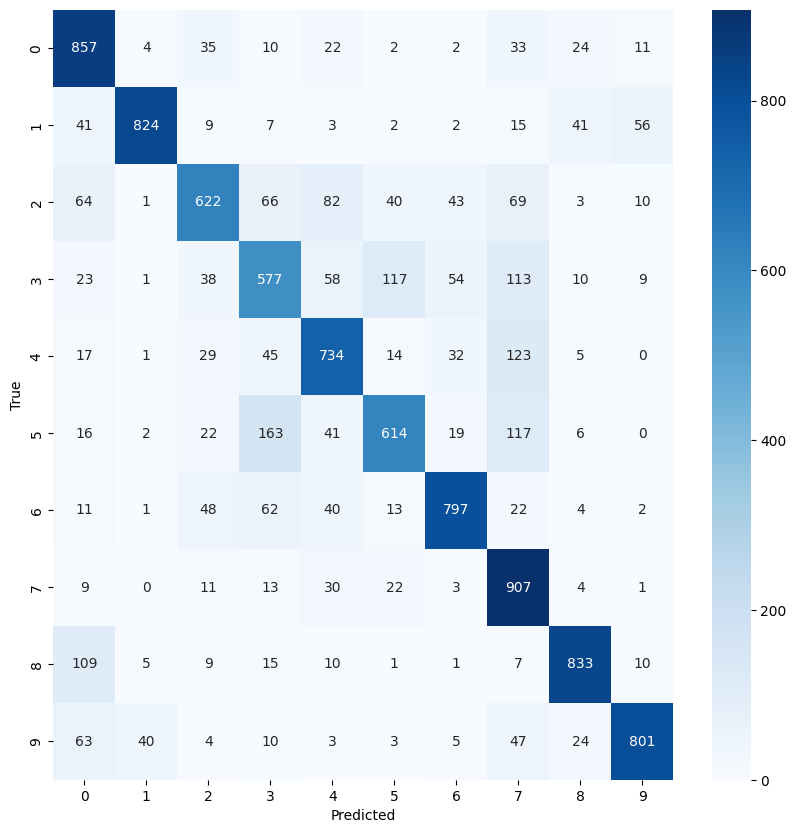

In [14]:
y_true=[]
y=pred=[]
with torch.no_grad():
  for images,labels in test_loader:
    images,labels=images.to(device),labels.to(device)
    outputs=model(images)
    _,predcited=torch.max(outputs,1)
    y_true.extend(labels.cpu().numpy())
    y.extend(predcited.cpu().numpy())
cm=confusion_matrix(y_true,y)
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [15]:
classes=train_dataset.classes

In [16]:
correct_class = list(0. for i in range(10))
total_class = list(0. for i in range(10))

with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    c = (predicted == labels).squeeze()
    for i in range(len(labels)):
      label = labels[i]
      correct_class[label] += c[i].item()
      total_class[label] += 1

for i in range(10):
  acc = 100 * correct_class[i] / total_class[i]
  print(f'{classes[i]}: {acc:.2f}%')

airplane: 85.70%
automobile: 82.40%
bird: 62.20%
cat: 57.70%
deer: 73.40%
dog: 61.40%
frog: 79.70%
horse: 90.70%
ship: 83.30%
truck: 80.10%


In [19]:
torch.save(model.state_dict(), "CIFAR10_PYTORCH.PT")

In [21]:
import gradio as gr
from PIL import Image
preprocess_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

def predict_image(input_img: Image.Image):
    # Preprocess the input image
    img_tensor = preprocess_transform(input_img).unsqueeze(0) # Add batch dimension
    img_tensor = img_tensor.to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)[0]

    # Convert probabilities to a dictionary for Gradio Label output
    predictions = {classes[i]: float(probabilities[i]) for i in range(len(classes))}
    return predictions

# Create the Gradio Interface
iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload Image"),
    outputs=gr.Label(num_top_classes=3, label="Prediction"),
    title="CIFAR-10 Image Classifier",
    description="Upload an image to classify it using the trained CIFAR-10 CNN model."
)

# Launch the interface
iface.launch(inline=True, share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://79a363afb3feaeadfc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
